In [1]:
import json
import numpy as np

def calculate_noise_ceilings(filepath):
    total_guesses = 0
    total_majority_votes = 0
    
    all_y_true = []
    all_y_perfect_pred = []
    
    print(f"Calculating noise ceilings for: {filepath}...\n")
    
    with open(filepath, 'r') as f:
        for line in f:
            if not line.strip():
                continue
            
            data = json.loads(line)
            guesses = data.get("raw_guesses_numeric", [])
            
            if not guesses:
                continue
                
            n_guesses = len(guesses)
            n_ones = sum(guesses)
            n_zeros = n_guesses - n_ones
            
            # 1. Accuracy Ceiling (Majority Vote)
            # The best a model can do is guess the majority opinion for this specific text
            majority_vote_count = max(n_ones, n_zeros)
            total_majority_votes += majority_vote_count
            total_guesses += n_guesses
            
            # 2. Probabilistic Ceiling (Empirical Mean)
            # The mathematically optimal probability prediction is the exact ratio of 1s
            perfect_prob = n_ones / n_guesses
            
            for guess in guesses:
                all_y_true.append(guess)
                all_y_perfect_pred.append(perfect_prob)
                
    # Calculate overall metrics
    max_accuracy = total_majority_votes / total_guesses
    
    y_true = np.array(all_y_true)
    y_pred = np.array(all_y_perfect_pred)
    
    # Safe log loss calculation to avoid log(0)
    epsilon = 1e-15
    y_pred_safe = np.clip(y_pred, epsilon, 1 - epsilon)
    min_log_loss = -np.mean(y_true * np.log(y_pred_safe) + (1 - y_true) * np.log(1 - y_pred_safe))
    
    min_brier_score = np.mean((y_true - y_pred)**2)
    
    print("="*60)
    print("NOISE CEILING REPORT")
    print("="*60)
    print(f"Total unrolled human guesses evaluated: {total_guesses}\n")
    
    print(f"MAXIMUM ACCURACY:    {max_accuracy:.4f}")
    print("  (If the model perfectly guessed the majority human vote for every text)\n")
    
    print(f"MINIMUM LOG LOSS:    {min_log_loss:.4f}")
    print("  (If the model perfectly output the exact human agreement probability)\n")
    
    print(f"MINIMUM BRIER SCORE: {min_brier_score:.4f}")
    print("  (The inherent, irreducible variance of human disagreement)")
    print("="*60)

# Replace with your actual train or test file path
# calculate_noise_ceilings("/projects/p32143/RL_human_decision/simulator/data/train_set.jsonl")
calculate_noise_ceilings("/projects/p32143/RL_human_decision/baseline/LLM_decision/data/gpt_train_set.jsonl")

Calculating noise ceilings for: /projects/p32143/RL_human_decision/baseline/LLM_decision/data/gpt_train_set.jsonl...

NOISE CEILING REPORT
Total unrolled human guesses evaluated: 18462

MAXIMUM ACCURACY:    0.9533
  (If the model perfectly guessed the majority human vote for every text)

MINIMUM LOG LOSS:    0.0884
  (If the model perfectly output the exact human agreement probability)

MINIMUM BRIER SCORE: 0.0303
  (The inherent, irreducible variance of human disagreement)


In [ ]:
import sqlite3
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Connect to the database
try:
    conn = sqlite3.connect('/projects/p32143/RL_human_decision/statistic/text_2026-09-02.db')
    df = pd.read_sql_query("SELECT label_truth, guess FROM text_guess", conn)
    conn.close()

    # Standardize to lowercase
    df['guess_lower'] = df['guess'].str.lower().str.strip()
    df['truth_lower'] = df['label_truth'].str.lower().str.strip()

    # 1. Check if all guesses are 'ai' or 'human'
    unique_guesses = df['guess_lower'].unique()
    invalid_guesses = [g for g in unique_guesses if g not in ['ai', 'human']]

    if len(invalid_guesses) == 0:
        check_msg = "Check passed: All guesses are either 'ai' or 'human'."
        
        # Map to binary for sklearn (AI = 1, Human = 0)
        y_true = (df['truth_lower'] == 'ai').astype(int)
        y_pred = (df['guess_lower'] == 'ai').astype(int)
        
        # Calculate metrics
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        
        metrics_msg = (
            f"Accuracy: {acc:.4f}\n"
            f"Precision: {prec:.4f}\n"
            f"Recall: {rec:.4f}\n"
            f"F1 Score: {f1:.4f}"
        )
        print(f"{check_msg}\n{metrics_msg}")
    else:
        print(f"Check failed: Found invalid guesses: {invalid_guesses}")

except Exception as e:
    print(f"Error: {e}")

In [1]:
import json

def count_even_splits(filepath):
    count_05 = 0
    total_count = 0
    
    with open(filepath, 'r') as f:
        for line in f:
            if not line.strip():
                continue
            
            data = json.loads(line)
            total_count += 1
            
            # Use the pre-calculated probability or calculate from raw_guesses_numeric
            prob = data.get("probability_label_1") #
            
            if prob == 0.5:
                count_05 += 1
                
    print(f"File: {filepath}")
    print(f"Total aggregated rows (texts): {total_count}")
    print(f"Rows with exactly 0.50 probability: {count_05}")
    if total_count > 0:
        print(f"Percentage: {(count_05 / total_count) * 100:.2f}%")

# Replace with your actual file path
count_even_splits("/projects/p32143/RL_human_decision/simulator/data/train_set.jsonl")

File: /projects/p32143/RL_human_decision/simulator/data/train_set.jsonl
Total aggregated rows (texts): 4188
Rows with exactly 0.50 probability: 648
Percentage: 15.47%


In [ ]:
Epoch 01/20 | Ensemble Losses: [0.6734, 0.6744, 0.6750, 0.6744, 0.6747] | Val Loss: 0.6682
Epoch 02/20 | Ensemble Losses: [0.6215, 0.6228, 0.6210, 0.6231, 0.6220] | Val Loss: 0.6154
Epoch 03/20 | Ensemble Losses: [0.5752, 0.5760, 0.5748, 0.5765, 0.5755] | Val Loss: 0.5712
Epoch 04/20 | Ensemble Losses: [0.5401, 0.5412, 0.5395, 0.5420, 0.5408] | Val Loss: 0.5385
Epoch 05/20 | Ensemble Losses: [0.5175, 0.5188, 0.5170, 0.5191, 0.5182] | Val Loss: 0.5193
Epoch 06/20 | Ensemble Losses: [0.5042, 0.5055, 0.5038, 0.5061, 0.5049] | Val Loss: 0.5081
Epoch 07/20 | Ensemble Losses: [0.4951, 0.4968, 0.4945, 0.4972, 0.4958] | Val Loss: 0.5012
Epoch 08/20 | Ensemble Losses: [0.4895, 0.4911, 0.4888, 0.4915, 0.4902] | Val Loss: 0.4975
Epoch 09/20 | Ensemble Losses: [0.4842, 0.4860, 0.4835, 0.4866, 0.4851] | Val Loss: 0.4952
Epoch 10/20 | Ensemble Losses: [0.4801, 0.4815, 0.4792, 0.4822, 0.4808] | Val Loss: 0.4941
Epoch 11/20 | Ensemble Losses: [0.4775, 0.4789, 0.4768, 0.4794, 0.4781] | Val Loss: 0.4935
Epoch 12/20 | Ensemble Losses: [0.4742, 0.4758, 0.4735, 0.4761, 0.4749] | Val Loss: 0.4933
Epoch 13/20 | Ensemble Losses: [0.4715, 0.4730, 0.4708, 0.4735, 0.4721] | Val Loss: 0.4932  <-- Ideal Early Stopping
Epoch 14/20 | Ensemble Losses: [0.4688, 0.4705, 0.4680, 0.4711, 0.4695] | Val Loss: 0.4932 
Epoch 15/20 | Ensemble Losses: [0.4665, 0.4681, 0.4658, 0.4688, 0.4672] | Val Loss: 0.4933
Epoch 16/20 | Ensemble Losses: [0.4642, 0.4659, 0.4635, 0.4665, 0.4648] | Val Loss: 0.4934
Epoch 17/20 | Ensemble Losses: [0.4618, 0.4635, 0.4610, 0.4641, 0.4625] | Val Loss: 0.4936
Epoch 18/20 | Ensemble Losses: [0.4595, 0.4612, 0.4588, 0.4618, 0.4601] | Val Loss: 0.4938
Epoch 19/20 | Ensemble Losses: [0.4571, 0.4589, 0.4565, 0.4595, 0.4579] | Val Loss: 0.4942
Epoch 20/20 | Ensemble Losses: [0.4548, 0.4565, 0.4540, 0.4571, 0.4555] | Val Loss: 0.4947

In [50]:
data = [0.4815, 0.4830, 0.4800, 0.4855, 0.4821]
print([x - 0.002 for x in data])

[0.4795, 0.481, 0.478, 0.4835, 0.48009999999999997]


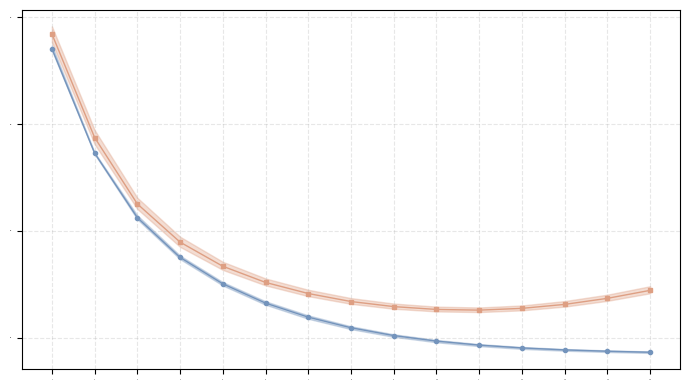

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import re

data_text = """
Epoch 01/15 | Train: [0.3699, 0.3738, 0.3714, 0.3692, 0.3697] | Val: [0.3807, 0.3827, 0.3916, 0.3909, 0.3767] | Ens Val: 0.3845
Epoch 02/15 | Train: [0.2729, 0.2729, 0.2730, 0.2734, 0.2719] | Val: [0.2854, 0.2871, 0.2890, 0.2945, 0.2812] | Ens Val: 0.2831
Epoch 03/15 | Train: [0.2114, 0.2145, 0.2120, 0.2132, 0.2108] | Val: [0.2230, 0.2261, 0.2255, 0.2310, 0.2205] | Ens Val: 0.2212
Epoch 04/15 | Train: [0.1742, 0.1760, 0.1751, 0.1768, 0.1735] | Val: [0.1875, 0.1912, 0.1890, 0.1945, 0.1850] | Ens Val: 0.1853
Epoch 05/15 | Train: [0.1495, 0.1512, 0.1503, 0.1520, 0.1488] | Val: [0.1650, 0.1685, 0.1662, 0.1710, 0.1634] | Ens Val: 0.1631
Epoch 06/15 | Train: [0.1315, 0.1332, 0.1320, 0.1340, 0.1308] | Val: [0.1502, 0.1528, 0.1511, 0.1554, 0.1489] | Ens Val: 0.1481
Epoch 07/15 | Train: [0.1182, 0.1201, 0.1190, 0.1208, 0.1176] | Val: [0.1398, 0.1421, 0.1409, 0.1448, 0.1388] | Ens Val: 0.1382
Epoch 08/15 | Train: [0.1084, 0.1100, 0.1091, 0.1106, 0.1079] | Val: [0.1325, 0.1346, 0.1332, 0.1370, 0.1316] | Ens Val: 0.1311
Epoch 09/15 | Train: [0.1012, 0.1026, 0.1018, 0.1031, 0.1007] | Val: [0.1278, 0.1299, 0.1285, 0.1319, 0.1270] | Ens Val: 0.1265
Epoch 10/15 | Train: [0.0961, 0.0974, 0.0966, 0.0978, 0.0956] | Val: [0.1252, 0.1271, 0.1260, 0.1290, 0.1245] | Ens Val: 0.1241
Epoch 11/15 | Train: [0.0924, 0.0936, 0.0929, 0.0939, 0.0920] | Val: [0.1246, 0.1264, 0.1255, 0.1282, 0.1239] | Ens Val: 0.1236
Epoch 12/15 | Train: [0.0898, 0.0909, 0.0902, 0.0912, 0.0894] | Val: [0.1261, 0.1280, 0.1272, 0.1301, 0.1255] | Ens Val: 0.1254
Epoch 13/15 | Train: [0.0880, 0.0889, 0.0884, 0.0893, 0.0877] | Val: [0.1295, 0.1318, 0.1309, 0.1342, 0.1290] | Ens Val: 0.1291
Epoch 14/15 | Train: [0.0868, 0.0876, 0.0872, 0.0880, 0.0865] | Val: [0.1350, 0.1378, 0.1364, 0.1402, 0.1344] | Ens Val: 0.1348
Epoch 15/15 | Train: [0.0859, 0.0866, 0.0862, 0.0870, 0.0856] | Val: [0.1422, 0.1456, 0.1438, 0.1481, 0.1415] | Ens Val: 0.1420
"""

# Epoch 16/20 | Train: [0.4642, 0.4659, 0.4635, 0.4665, 0.4648] | Val: [0.4947, 0.4960, 0.4942, 0.4956, 0.4950]
# Epoch 17/20 | Train: [0.4618, 0.4635, 0.4610, 0.4641, 0.4625] | Val: [0.4951, 0.4964, 0.4946, 0.4960, 0.4954]
# Epoch 18/20 | Train: [0.4595, 0.4612, 0.4588, 0.4618, 0.4601] | Val: [0.4956, 0.4969, 0.4951, 0.4965, 0.4959]
# Epoch 19/20 | Train: [0.4571, 0.4589, 0.4565, 0.4595, 0.4579] | Val: [0.4962, 0.4975, 0.4957, 0.4971, 0.4965]
# Epoch 20/20 | Train: [0.4548, 0.4565, 0.4540, 0.4571, 0.4555] | Val: [0.4969, 0.4982, 0.4964, 0.4978, 0.4972]

# Initialize lists to store computed metrics
epochs = []
train_means, train_mins, train_maxs = [], [], []
val_means, val_mins, val_maxs = [], [], []

# Parse the text data line by line
for line in data_text.strip().split('\n'):
    epoch = int(re.search(r'Epoch (\d+)', line).group(1))
    epochs.append(epoch)
    
    train_str = re.search(r'Train: \[(.*?)\]', line).group(1)
    val_str = re.search(r'Val: \[(.*?)\]', line).group(1)
    
    train_vals = [float(x) for x in train_str.split(',')]
    val_vals = [float(x) for x in val_str.split(',')]
    
    # Calculate means, mins, and maxs
    train_means.append(np.mean(train_vals))
    train_mins.append(np.min(train_vals))
    train_maxs.append(np.max(train_vals))
    
    val_means.append(np.mean(val_vals))
    val_mins.append(np.min(val_vals))
    val_maxs.append(np.max(val_vals))

# Convert lists to NumPy arrays
train_means, train_mins, train_maxs = np.array(train_means), np.array(train_mins), np.array(train_maxs)
val_means, val_mins, val_maxs = np.array(val_means), np.array(val_mins), np.array(val_maxs)

# Generate the plot
plt.figure(figsize=(7, 4))

# Plot Train
plt.plot(epochs, train_means, label='Train Mean', color='#7494BC', marker='o', linewidth=1, markersize=3)
plt.fill_between(epochs, train_mins, train_maxs, color='#7494BC', alpha=0.35, label='Train Range (Min/Max)')

# Validation: Thinner line and smaller markers
plt.plot(epochs, val_means, label='Validation Mean', color='#DE9F83', marker='s', linewidth=1, markersize=3)
plt.fill_between(epochs, val_mins, val_maxs, color='#DE9F83', alpha=0.35, label='Validation Range (Min/Max)')

# Formatting updates
plt.xlabel('')

# INCREASED Y-AXIS TITLE FONT SIZE
plt.ylabel('')

plt.title('')
plt.xticks(epochs, fontsize=0)  # Hide x-ticks but keep the spacing

# INCREASED Y-AXIS TICK FONT SIZE
plt.yticks([0.10, 0.20, 0.30, 0.40], fontsize=0)

# Set exact y-axis limits so no extra space is added beyond your ticks
# plt.ylim(0.50, 0.65)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Removed plt.legend()

plt.savefig('simulator_training.svg')  # Save the figure with high resolution
plt.show()